# Code to plot the timing of maximum/minimum of a 2D field over a model/analysis domain

In [2]:
import numpy as np
import matplotlib.pyplot as mp
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import matplotlib.colors as colors
#from mpl_toolkits.basemap import Basemap as bmap
import shapely.geometry as sgeom
import cftime
from datetime import timedelta
import calendar as cal

import xarray as xr
import datetime as dt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

import pandas as pd
import glob as glob


In [8]:
# Read in climo files and concatonate

case = 'f.e20.FHIST.f09_f09.cesm2_1.001'
#case = 'ERAI'






# Reanlysis or Models


if case in ['ERAI','MERRA','TRMM']:

    dir0 = '/glade/p/cesm/amwg/amwg_data/obs_data/'
    
    indir = dir0+case+'_??_climo.nc'
    
else:
#dir0 = '/glade/scratch/rneale/archive/'
    dir0 = '/glade/campaign/cgd/amp/amwg/climo/'
#dir0 = '/glade/p/cgd/amp/people/hannay/amwg/climo/'

#indir = dir0+case+'/0.9x1.25/'+case+'_{01,02,03,04,05,06,07,08,09,10,11,12}_climo.nc'
    indir = dir0+case+'/0.9x1.25/'+case+'_??_climo.nc'
print(indir)

climo_files = glob.glob(indir)  # List all files in variable directory
climo_files = sorted(climo_files)



# Other stuff
pdir = '/glade/u/home/rneale/python/python-figs/vert_proc/transition_pod/'

climo_files

/glade/campaign/cgd/amp/amwg/climo/f.e20.FHIST.f09_f09.cesm2_1.001/0.9x1.25/f.e20.FHIST.f09_f09.cesm2_1.001_??_climo.nc


['/glade/campaign/cgd/amp/amwg/climo/f.e20.FHIST.f09_f09.cesm2_1.001/0.9x1.25/f.e20.FHIST.f09_f09.cesm2_1.001_01_climo.nc',
 '/glade/campaign/cgd/amp/amwg/climo/f.e20.FHIST.f09_f09.cesm2_1.001/0.9x1.25/f.e20.FHIST.f09_f09.cesm2_1.001_02_climo.nc',
 '/glade/campaign/cgd/amp/amwg/climo/f.e20.FHIST.f09_f09.cesm2_1.001/0.9x1.25/f.e20.FHIST.f09_f09.cesm2_1.001_03_climo.nc',
 '/glade/campaign/cgd/amp/amwg/climo/f.e20.FHIST.f09_f09.cesm2_1.001/0.9x1.25/f.e20.FHIST.f09_f09.cesm2_1.001_04_climo.nc',
 '/glade/campaign/cgd/amp/amwg/climo/f.e20.FHIST.f09_f09.cesm2_1.001/0.9x1.25/f.e20.FHIST.f09_f09.cesm2_1.001_05_climo.nc',
 '/glade/campaign/cgd/amp/amwg/climo/f.e20.FHIST.f09_f09.cesm2_1.001/0.9x1.25/f.e20.FHIST.f09_f09.cesm2_1.001_06_climo.nc',
 '/glade/campaign/cgd/amp/amwg/climo/f.e20.FHIST.f09_f09.cesm2_1.001/0.9x1.25/f.e20.FHIST.f09_f09.cesm2_1.001_07_climo.nc',
 '/glade/campaign/cgd/amp/amwg/climo/f.e20.FHIST.f09_f09.cesm2_1.001/0.9x1.25/f.e20.FHIST.f09_f09.cesm2_1.001_08_climo.nc',
 '/glade

In [9]:
## Read in data and concatonate

#ds_climo = xr.open_mfdataset(climo_files, decode_cf=True, decode_times = True, parallel=True) # 3
ds_climo = xr.open_mfdataset(climo_files,decode_cf=True, decode_times = True, parallel=True) 
ds_climo

<xarray.Dataset>
Dimensions:           (lat: 192, lon: 288, time: 12, lev: 32, ilev: 33, nbnd: 2)
Coordinates:
  * lat               (lat) float64 -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon               (lon) float64 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
  * lev               (lev) float64 3.643 7.595 14.36 ... 957.5 976.3 992.6
  * ilev              (ilev) float64 2.255 5.032 10.16 ... 967.5 985.1 1e+03
  * time              (time) object 1995-02-01 00:00:00 ... 1996-01-01 00:00:00
Dimensions without coordinates: nbnd
Data variables: (12/452)
    gw                (time, lat) float64 dask.array<chunksize=(1, 192), meta=np.ndarray>
    hyam              (time, lev) float64 dask.array<chunksize=(1, 32), meta=np.ndarray>
    hybm              (time, lev) float64 dask.array<chunksize=(1, 32), meta=np.ndarray>
    P0                (time) float64 1e+05 1e+05 1e+05 ... 1e+05 1e+05 1e+05
    hyai              (time, ilev) float64 dask.array<chunksize=(1, 33), meta=np.ndarray>
    hybi              (time, ilev) float64 dask.array<chunksize=(1, 33), meta=np.ndarray>
    ...                ...
    soa_a2SFWET       (time, lat, lon) float32 dask.array<chunksize=(1, 192, 288), meta=np.ndarray>
    soa_a2_SRF        (time, lat, lon) float32 dask.array<chunksize=(1, 192, 288), meta=np.ndarray>
    soa_c1            (time, lev, lat, lon) float32 dask.array<chunksize=(1, 32, 192, 288), meta=np.ndarray>
    soa_c1SFWET       (time, lat, lon) float32 dask.array<chunksize=(1, 192, 288), meta=np.ndarray>
    soa_c2            (time, lev, lat, lon) float32 dask.array<chunksize=(1, 32, 192, 288), meta=np.ndarray>
    soa_c2SFWET       (time, lat, lon) float32 dask.array<chunksize=(1, 192, 288), meta=np.ndarray>
Attributes: (12/15)
    Conventions:                CF-1.0
    source:                     CAM
    case:                       f.e20.FHIST.f09_f09.cesm2_1.001
    logname:                    hannay
    host:                       cheyenne1
    initial_file:               b.e21.BHIST.f09_g17.CMIP6-historical.001.cam....
    ...                         ...
    history:                    Fri Jun  5 08:25:38 2020: ncatted -O -a yrs_a...
    NCO:                        netCDF Operators version 4.7.9 (Homepage = ht...
    nco_input_file_number:      19
    nco_input_file_list:        /glade/p/cgd/amp/people/hannay/amwg//climo/f....
    history_of_appended_files:  Fri Jun  5 08:25:30 2020: Appended file /glad...
    yrs_averaged:               1986-2004

['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
0
11


/glade/work/rneale/python/miniconda3/envs/neale_myenv/lib/python3.8/site-packages/cartopy/crs.py:825: ShapelyDeprecationWarning: __len__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Check the length of the `geoms` property instead to get the  number of parts of a multi-part geometry.
  if len(multi_line_string) > 1:
/glade/work/rneale/python/miniconda3/envs/neale_myenv/lib/python3.8/site-packages/cartopy/crs.py:836: ShapelyDeprecationWarning: __len__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Check the length of the `geoms` property instead to get the  number of parts of a multi-part geometry.
  line_strings = list(multi_line_string)
/glade/work/rneale/python/miniconda3/envs/neale_myenv/lib/python3.8/site-packages/cartopy/crs.py:836: ShapelyDeprecationWarning: Iteration over multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geome

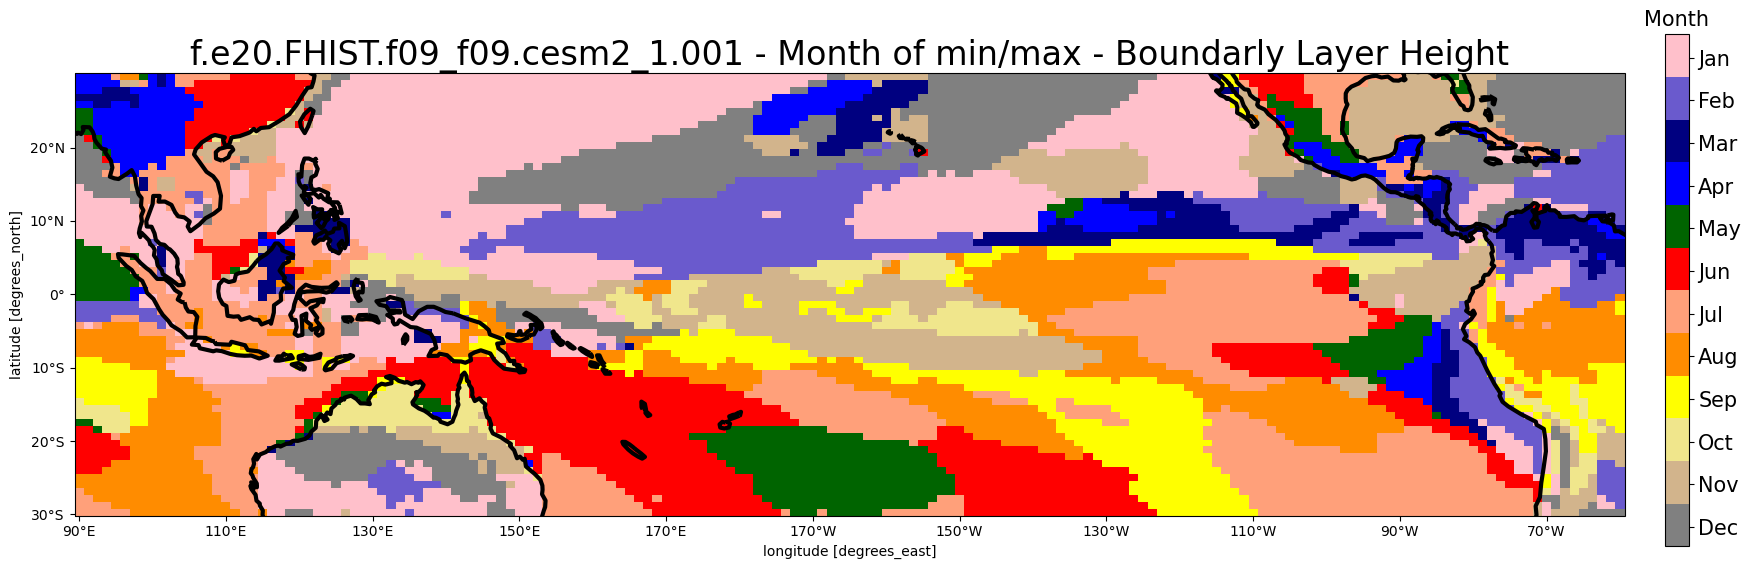

In [10]:
lat_min = -30; lat_max = 30
lon_min=90 ; lon_max = 300

#vname = 'PRECT' ; long_name = "Precipitation"

#vname = 'TS'  ; long_name = 'Surface Temperature'
vname = 'PBLH'; long_name = 'Boundarly Layer Height'


ds_climo = ds_climo.sel(lat=slice(lat_min,lat_max), lon=slice(lon_min,lon_max))

da_plot = ds_climo.PRECL+ds_cimo.PRECC if vname == 'PRECT' else ds_climo[vname]
da_plot = da_plot.argmax(dim='time')

clevsi = [0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5,8.5,9.5,10.5,11.5,12.5]
#clevsi = [0,1,2,3,4,5,6,7,8,9,10,11,12]
clevsm = cal.month_abbr[1:]
#clevsm = clevsm[0:]
print(clevsm)

ccols =  ['gray','tan','khaki','yellow','darkorange','lightsalmon','red','darkgreen','blue','navy','slateblue','pink']
ccols.reverse()
cmap = colors.ListedColormap(ccols)


cc_pc = ccrs.PlateCarree(central_longitude=180)
tcc_pc = ccrs.PlateCarree()

fig,axl =  mp.subplots(ncols=1,nrows=1,
                        subplot_kw={'projection': cc_pc},
                        figsize=(20,8))

fig.patch.set_facecolor('white') 

axl.coastlines(color='black',linewidth=3)

print(da_plot.values.min())
print(da_plot.values.max())


im = da_plot.plot.pcolormesh(ax=axl, transform=tcc_pc,cmap=cmap,rasterized=True,add_colorbar=False)


# Axes settings
lon_formatter = LongitudeFormatter(zero_direction_label=True)
lat_formatter = LatitudeFormatter()

axl.xaxis.set_major_formatter(lon_formatter)
axl.yaxis.set_major_formatter(lat_formatter)

axl.set_xticks(np.arange(lon_min,lon_max,20), crs=tcc_pc)
axl.set_yticks(np.arange(lat_min,lat_max,10), crs=tcc_pc)

axl.set_title(case+' - Month of min/max - '+long_name,fontsize=24)    



# Color bar
cbar_ax = fig.add_axes([0.92, 0.18, 0.012, 0.64])
cbar_ax.set_title('Month',fontsize=15)
colb1= mp.colorbar(im, cax=cbar_ax, orientation="vertical",ticks=0.5+(11/12)*np.arange(np.min(da_plot),np.max(da_plot)+1))
colb1.ax.set_yticklabels(clevsm,fontsize=15)
cbar_ax.invert_yaxis()

mp.savefig(pdir+'max_month.'+vname+'.'+case+'.png', dpi=70,bbox_inches='tight') 
